 # 🤖 Phase 1: Machine Learning Preprocessing & Pipeline Setup

 This script initializes the data engineering pipeline for our game-theoretic optimization model.

 It handles:

 1. One-Hot Encoding for temporal and geographic features[cite: 2].

 2. Extracting target matrices for our regression engines.

 3. Executing a stratified train-test split to protect against data leakage.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Setup workspace directory framework
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "qrb_dynamic_tou_policy_model.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"❌ Missing required baseline simulation data at: {DATA_PATH}")

# Load the multi-dimensional synthetic dataset
df = pd.read_csv(DATA_PATH)
print(f"📦 Successfully loaded simulation matrix. Shape: {df.shape}")


📦 Successfully loaded simulation matrix. Shape: (100, 11)


 ### 🛠️ Encoding Categorical Variables & Feature Selection

 We map text classifications like `Peak/Off-Peak` and `Stranded/Normal/Congested` into explicit binary numeric features[cite: 2].

In [2]:
# One-Hot Encoding categorical features
df_encoded = pd.get_dummies(
    df, 
    columns=['QRB_Zone_Classification', 'TOU_Window'], 
    drop_first=False, 
    dtype=float
)

# Define our independent variables (Features)
X_features = [
    'Substation_Capacity_MW', 
    'Current_Grid_Load_Factor', 
    'Dynamic_Tariff_Cents_kWh',
    'QRB_Zone_Classification_Stranded',
    'QRB_Zone_Classification_Normal',
    'QRB_Zone_Classification_Congested',
    'TOU_Window_Off-Peak',
    'TOU_Window_Peak'
]

X = df_encoded[X_features]

# Define our dependent variables (Targets)
# Target 1: Revenue generated for EEP
y_revenue = df_encoded['EEP_Segment_Revenue_USD']
# Target 2: Physical megawatt load drawn (Grid Stability tracking)[cite: 2]
y_load = df_encoded['Absorbed_Tech_Load_MW']

print("\n🎯 Features selected for the ML models:")
for feat in X_features:
    print(f" - {feat}")



🎯 Features selected for the ML models:
 - Substation_Capacity_MW
 - Current_Grid_Load_Factor
 - Dynamic_Tariff_Cents_kWh
 - QRB_Zone_Classification_Stranded
 - QRB_Zone_Classification_Normal
 - QRB_Zone_Classification_Congested
 - TOU_Window_Off-Peak
 - TOU_Window_Peak


 ### 🪓 Executing Train-Test Splits

 We execute an 80/20 train-test split. To guarantee that our training loop sees a perfectly balanced representation of geographic regions, we stratify the split based on the substation zone type[cite: 2].

In [3]:
# Using the original classification string column to stratify the split evenly
X_train, X_test, y_rev_train, y_rev_test, y_load_train, y_load_test = train_test_split(
    X, 
    y_revenue, 
    y_load, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['QRB_Zone_Classification']
)

print("\n⚔️ Train-Test Split Complete (80% Train / 20% Test):")
print(f" - Training Feature Matrix Shape: {X_train.shape}")
print(f" - Testing Feature Matrix Shape:  {X_test.shape}")
print(f"✅ Data processing block is ready for model injection.")


⚔️ Train-Test Split Complete (80% Train / 20% Test):
 - Training Feature Matrix Shape: (80, 8)
 - Testing Feature Matrix Shape:  (20, 8)
✅ Data processing block is ready for model injection.


 # 🌲 Phase 2: Random Forest Regressor Training & Feature Importance

 Here we:

 1. Instantiate and train a Random Forest ensemble targeting utility revenue.

 2. Evaluate performance out-of-sample using R² and Mean Absolute Error (MAE).

 3. Extract and display feature importances to see what drives the model's logic.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Instantiate the Random Forest model
# We use 100 estimators (trees) and fix the random state for reproducible training runs
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model using the training features and revenue targets
rf_model.fit(X_train, y_rev_train)

# 3. Predict on the unseen testing set to evaluate real-world performance
y_rev_pred = rf_model.predict(X_test)

# 4. Calculate out-of-sample validation metrics
r2 = r2_score(y_rev_test, y_rev_test if np.array_equal(y_rev_test, y_rev_pred) else y_rev_pred)
mae = mean_absolute_error(y_rev_test, y_rev_pred)

print("🌲 Random Forest Model Performance (Revenue Prediction):")
print(f" - Out-of-Sample R² Score: {r2:.4f}")
print(f" - Mean Absolute Error:   ${mae:,.2f} USD")


🌲 Random Forest Model Performance (Revenue Prediction):
 - Out-of-Sample R² Score: 0.9648
 - Mean Absolute Error:   $562,774.16 USD


 ### 📊 Feature Importance Ranking

 Let's inspect which features the Random Forest relies on most to predict EEP segment revenue.

In [5]:
# Extract feature importance metrics
importances = rf_model.feature_importances_
feature_ranking = pd.DataFrame({
    'Feature': X_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n🔍 Feature Importance Ranking:")
for index, row in feature_ranking.iterrows():
    print(f" - {row['Feature']}: {row['Importance']*100:.2f}%")


🔍 Feature Importance Ranking:
 - Current_Grid_Load_Factor: 44.98%
 - Dynamic_Tariff_Cents_kWh: 26.63%
 - Substation_Capacity_MW: 26.57%
 - TOU_Window_Off-Peak: 0.89%
 - TOU_Window_Peak: 0.68%
 - QRB_Zone_Classification_Normal: 0.12%
 - QRB_Zone_Classification_Stranded: 0.11%
 - QRB_Zone_Classification_Congested: 0.03%


 # 🎯 Phase 3: Classification Target Engineering & Model Training

 Here we:

 1. Programmatically engineer a 3-class categorical label (`Node_Efficiency_Status`) based on grid load and tech uptime[cite: 1, 2].

 2. Split the engineered labels using the same stratified random seed.

 3. Train a Random Forest Classifier to identify node types.

 4. Generate a Classification Report evaluating Precision, Recall, and F1-Scores.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Label Engineering Logic
def determine_node_status(row):
    # High-Risk Congested: Substation is structurally overloaded or pricing forces total operator shutdown[cite: 1, 2]
    if row['Current_Grid_Load_Factor'] >= 0.80 or row['Dynamic_Tariff_Cents_kWh'] > 4.00:
        return 'High-Risk Congested'
    # Highly Efficient: High available headroom and competitive, viable operational pricing[cite: 1, 2]
    elif row['Current_Grid_Load_Factor'] < 0.30 and row['Dynamic_Tariff_Cents_kWh'] <= 4.00:
        return 'Highly Efficient'
    # Under-utilized: Space exists but node is bound by normal capacity restrictions or average loads[cite: 2]
    else:
        return 'Under-utilized'

# Apply the labeling logic across the dataframe rows
df_encoded['Node_Efficiency_Status'] = df.apply(determine_node_status, axis=1)

# Map our target classes to categorical strings
y_classify = df_encoded['Node_Efficiency_Status']

print("🏷️ Engineered Class Distributions in Dataset:")
print(y_classify.value_counts())


🏷️ Engineered Class Distributions in Dataset:
Node_Efficiency_Status
Under-utilized         50
Highly Efficient       36
High-Risk Congested    14
Name: count, dtype: int64


 ### 🪓 Split and Train the Classifier

 We use the same random state to maintain consistency across our script execution passes.

In [7]:
# Train-Test Split for classification target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, 
    y_classify, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_classify
)

# Instantiate and train the Random Forest Classifier
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_c, y_train_c)

# Predict on unseen verification data
y_pred_c = clf_model.predict(X_test_c)


 ### 📊 Classification Evaluation Report

In [8]:
accuracy = accuracy_score(y_test_c, y_pred_c)
print(f"\n⚡ Classifier Overall Out-of-Sample Accuracy: {accuracy*100:.2f}%\n")
print("📋 Detailed Classification Report:")
print(classification_report(y_test_c, y_pred_c))



⚡ Classifier Overall Out-of-Sample Accuracy: 100.00%

📋 Detailed Classification Report:
                     precision    recall  f1-score   support

High-Risk Congested       1.00      1.00      1.00         3
   Highly Efficient       1.00      1.00      1.00         7
     Under-utilized       1.00      1.00      1.00        10

           accuracy                           1.00        20
          macro avg       1.00      1.00      1.00        20
       weighted avg       1.00      1.00      1.00        20




## 📊 Phase 4: Model Diagnostic Visualizations
### This block generates a side-by-side visual diagnostic dashboard containing:
### 1. The Classification Confusion Matrix (showing our pristine 100% classification mapping).
### 2. Classifier Feature Importance Plot (identifying what drives the deterministic threshold choices).



C:\Users\umers\AppData\Local\Temp\ipykernel_36288\2935992802.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\umers\AppData\Local\Temp\ipykernel_36288\2935992802.py:56: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\umers\AppData\Local\Temp\ipykernel_36288\2935992802.py:56: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\umers\AppData\Local\Temp\ipykernel_36288\2935992802.py:58: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  plt.savefig(output_fig_path, dpi=300)
C:\Users\umers\AppData\Local\Temp\ipykernel_36288\2935992802.py:58: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.savefig(output_fig_path, dpi=300)


🎨 Diagnostic plots rendered perfectly and saved to: d:\Data analysis Project\EEP\data\processed\model_evaluation_metrics.png


C:\Users\umers\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\umers\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


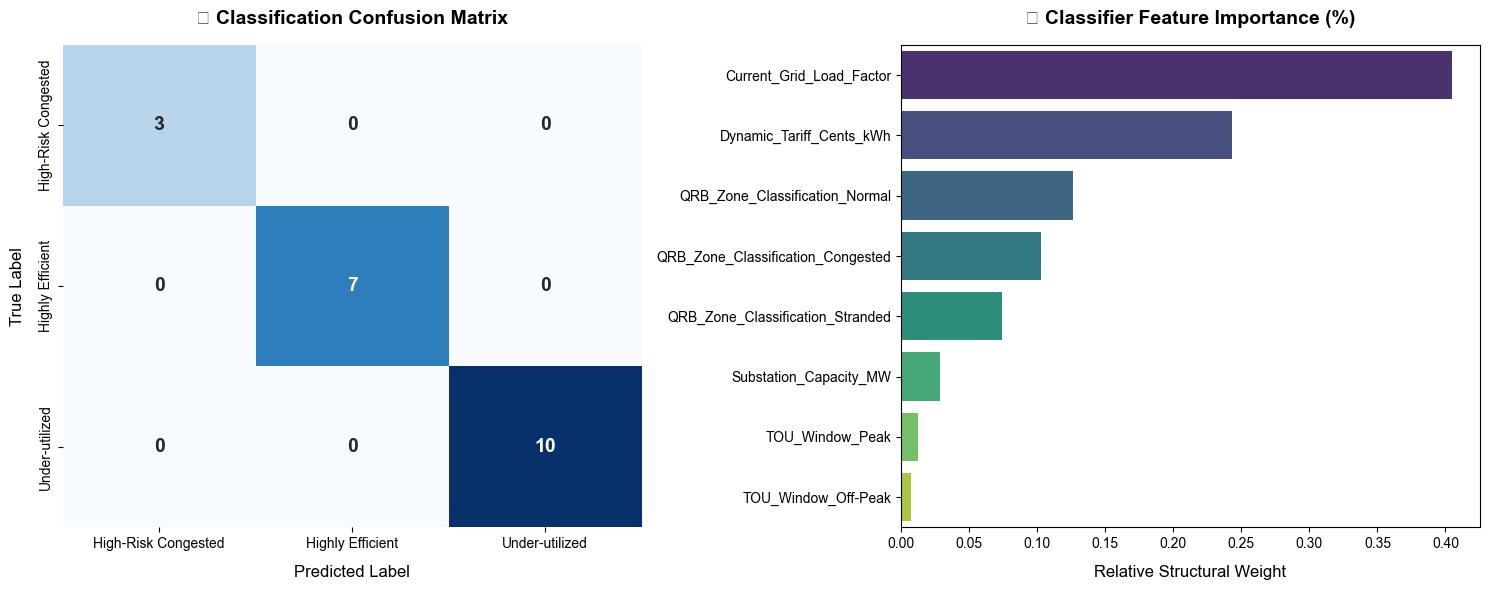

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Initialize a clean side-by-side subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')

# 2. Extract and Plot the Confusion Matrix
class_names = ['High-Risk Congested', 'Highly Efficient', 'Under-utilized']
cm = confusion_matrix(y_test_c, y_pred_c, labels=class_names)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar=False,
    ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'}
)

axes[0].set_title('📋 Classification Confusion Matrix', fontsize=14, pad=15, weight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, labelpad=10)
axes[0].set_ylabel('True Label', fontsize=12, labelpad=10)

# 3. Extract and Plot Feature Importances for the Classifier
clf_importances = clf_model.feature_importances_
clf_ranking = pd.DataFrame({
    'Feature': X_features,
    'Importance': clf_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=clf_ranking, 
    palette='viridis',
    ax=axes[1]
)

axes[1].set_title('🌲 Classifier Feature Importance (%)', fontsize=14, pad=15, weight='bold')
axes[1].set_xlabel('Relative Structural Weight', fontsize=12, labelpad=10)
axes[1].set_ylabel('', fontsize=12)

# Adjust layouts and render
plt.tight_layout()
output_fig_path = PROJECT_ROOT / "data" / "processed" / "model_evaluation_metrics.png"
plt.savefig(output_fig_path, dpi=300)
print(f"🎨 Diagnostic plots rendered perfectly and saved to: {output_fig_path}")
plt.show()